# Escalado y normalización

Este notebook explica qué problema resuelven el escalado y la normalización, y compara varios transformadores sobre un dataset más grande.

## Objetivos

- Entender por qué las escalas distintas afectan a algunos modelos.
- Comparar `StandardScaler`, `MinMaxScaler`, `RobustScaler` y normalización por fila.
- Ver el impacto sobre distancias y sobre un modelo con regularización.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(7)
pd.set_option('display.max_columns', None)

## 1. Crear dataset con escalas muy diferentes

In [2]:
n = 1500
df = pd.DataFrame({
    'ingreso_anual': rng.normal(55_000, 18_000, size=n).clip(8_000, 180_000),
    'saldo_promedio': rng.normal(12_000, 7_000, size=n).clip(0, 90_000),
    'n_transacciones_mes': rng.poisson(35, size=n),
    'porcentaje_utilizacion': rng.uniform(0, 1, size=n),
    'dias_mora_max': rng.integers(0, 120, size=n),
    'ratio_pago_minimo': rng.uniform(0.05, 1.0, size=n)
})

# introducir outliers
outlier_idx = rng.choice(df.index, size=20, replace=False)
df.loc[outlier_idx, 'ingreso_anual'] *= 3
df.loc[outlier_idx, 'saldo_promedio'] *= 4

score = (
    -0.00003 * df['ingreso_anual']
    +0.00006 * df['saldo_promedio']
    +0.015 * df['n_transacciones_mes']
    +1.6 * df['porcentaje_utilizacion']
    +0.018 * df['dias_mora_max']
    -1.2 * df['ratio_pago_minimo']
)
p = 1 / (1 + np.exp(-(score - score.mean())))
df['target'] = rng.binomial(1, p)
df.head()

,ingreso_anual,saldo_promedio,n_transacciones_mes,porcentaje_utilizacion,dias_mora_max,ratio_pago_minimo,target
0,55022.142760,3472.081821,33,0.533414,61,0.205298,0
1,60377.419675,23512.029404,36,0.295302,84,0.783527,1
2,50065.518603,15548.904867,26,0.781312,114,0.657559,1
3,38969.346902,24522.112185,41,0.431247,80,0.354705,1
4,46815.925867,17578.200544,35,0.649553,74,0.716982,1


## 2. Ver rangos antes de escalar

In [3]:
summary = pd.DataFrame({
    'min': df.drop(columns='target').min(),
    'max': df.drop(columns='target').max(),
    'media': df.drop(columns='target').mean(),
    'std': df.drop(columns='target').std()
})
summary

,min,max,media,std
ingreso_anual,8000.000000,244419.687262,55441.303935,21883.155940
saldo_promedio,0.000000,106684.968454,12616.699901,8911.536784
n_transacciones_mes,18.000000,57.000000,35.010667,5.945372
porcentaje_utilizacion,0.002404,0.999856,0.501891,0.290119
dias_mora_max,0.000000,119.000000,60.446000,35.408308
ratio_pago_minimo,0.050311,0.999352,0.532657,0.276302


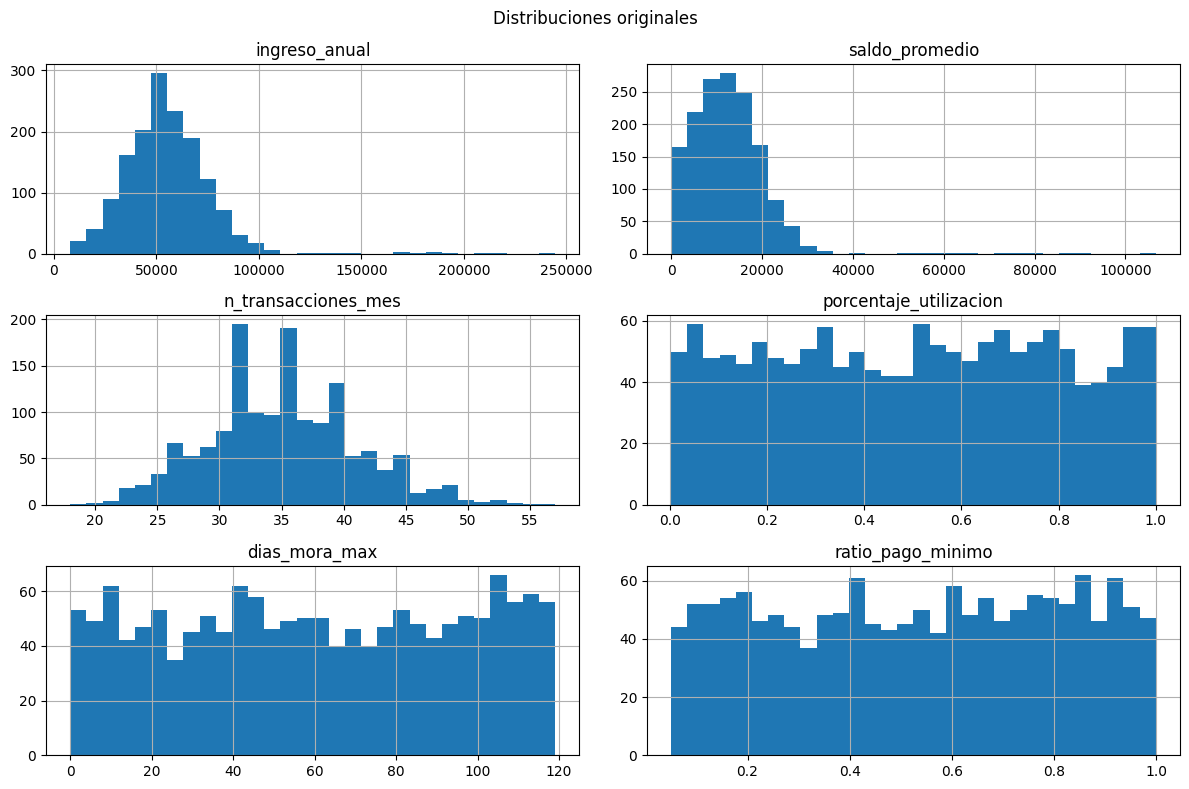

In [4]:
df.drop(columns='target').hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribuciones originales')
plt.tight_layout()
plt.show()

## 3. Separar train/test

In [5]:
X = df.drop(columns='target')
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=7)

## 4. Aplicar distintos escaladores

In [6]:
scalers = {
    'standard': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler()
}

scaled_examples = {}
for name, scaler in scalers.items():
    Xt = scaler.fit_transform(X_train)
    scaled_examples[name] = pd.DataFrame(Xt, columns=X_train.columns, index=X_train.index)

scaled_examples['standard'].head()

,ingreso_anual,saldo_promedio,n_transacciones_mes,porcentaje_utilizacion,dias_mora_max,ratio_pago_minimo
1219,-1.225506,0.077365,1.147165,-0.481005,-1.099148,-0.296533
580,0.209183,-0.966450,-2.176024,1.650077,1.138177,-0.888715
320,-0.655038,0.533107,-1.179068,0.274552,0.522912,0.210080
82,0.276886,0.601890,-1.012908,0.852063,1.501742,-1.465871
1086,0.927627,-0.329692,-0.182111,-1.151750,-0.288118,-1.381497


## 5. Comparar efectos sobre una misma fila

In [7]:
row_idx = X_train.index[0]
comparison = pd.concat([
    X_train.loc[[row_idx]].T.rename(columns={row_idx: 'original'}),
    scaled_examples['standard'].loc[[row_idx]].T.rename(columns={row_idx: 'standard'}),
    scaled_examples['minmax'].loc[[row_idx]].T.rename(columns={row_idx: 'minmax'}),
    scaled_examples['robust'].loc[[row_idx]].T.rename(columns={row_idx: 'robust'})
], axis=1)
comparison

,original,standard,minmax,robust
ingreso_anual,28753.346056,-1.225506,0.087782,-1.059886
saldo_promedio,13117.937402,0.077365,0.122960,0.155880
n_transacciones_mes,42.000000,1.147165,0.615385,0.875000
porcentaje_utilizacion,0.362253,-0.481005,0.359745,-0.311740
dias_mora_max,21.000000,-1.099148,0.176471,-0.603175
ratio_pago_minimo,0.455744,-0.296533,0.427202,-0.189399


## 6. Normalización por fila

La normalización no escala columnas; reescala cada observación para que su norma sea 1. Es muy útil en texto y en algunos contextos geométricos.

In [8]:
normalizer = Normalizer(norm='l2')
X_norm = pd.DataFrame(normalizer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_norm.head()

,ingreso_anual,saldo_promedio,n_transacciones_mes,porcentaje_utilizacion,dias_mora_max,ratio_pago_minimo
1219,0.909790,0.415067,0.001329,0.000011,0.000664,0.000014
580,0.997884,0.065002,0.000367,0.000016,0.001683,0.000005
320,0.923034,0.384715,0.000628,0.000013,0.001773,0.000013
82,0.960598,0.277936,0.000454,0.000012,0.001785,0.000002
1086,0.992131,0.125205,0.000447,0.000002,0.000657,0.000002


In [9]:
row_norms = np.linalg.norm(X_norm.values, axis=1)
pd.Series(row_norms).describe()

count    1.125000e+03
mean     1.000000e+00
std      8.654409e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

## 7. Impacto en un modelo

Vamos a comparar una regresión logística entrenada con y sin escalado.

In [10]:
def evaluate_model(Xtr, Xte, ytr, yte):
    model = LogisticRegression(max_iter=3000)
    model.fit(Xtr, ytr)
    pred = model.predict_proba(Xte)[:, 1]
    return roc_auc_score(yte, pred)

results = []

auc_raw = evaluate_model(X_train, X_test, y_train, y_test)
results.append(('sin_escalado', auc_raw))

for name, scaler in scalers.items():
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)
    auc = evaluate_model(Xtr, Xte, y_train, y_test)
    results.append((name, auc))

norm = Normalizer(norm='l2')
Xtr_norm = norm.fit_transform(X_train)
Xte_norm = norm.transform(X_test)
auc_norm = evaluate_model(Xtr_norm, Xte_norm, y_train, y_test)
results.append(('normalizer_l2', auc_norm))

pd.DataFrame(results, columns=['transformacion', 'auc']).sort_values('auc', ascending=False)

,transformacion,auc
1,standard,0.764393
3,robust,0.764222
0,sin_escalado,0.763028
2,minmax,0.760923
4,normalizer_l2,0.673057


## 8. ¿Cuál usar?

- `StandardScaler`: baseline general para muchos modelos lineales y métodos basados en distancia.
- `MinMaxScaler`: útil si necesitas un rango fijo.
- `RobustScaler`: preferible con outliers.
- `Normalizer`: útil cuando importa la dirección del vector más que la magnitud.

## 9. Conclusiones

puede cambiar significativamente el comportamiento de un modelo y de las distancias. Siempre conviene elegir la transformación según el algoritmo y la naturaleza de los datos.